In [109]:
from tms_risk.cogmodels.fit_model import build_model, get_data
from tms_risk.cogmodels.utils import plot_prediction, stimulation_order, stimulation_palette
import seaborn as sns
import arviz as az
import os.path as op
import pandas as pd
import matplotlib.pyplot as plt
from bauer.utils.math import softplus_np
import numpy as np
from bauer.models import FlexibleNoiseRiskRegressionModel
from tqdm import tqdm
import pandas as pd

bids_folder = '/data/ds-tmsrisk'

# Some convenience functions
def get_info(model_label, bids_folder='/data/ds-tmsrisk'):

    df = get_data(model_label=model_label, bids_folder=bids_folder)
    model = build_model(df=df, model_label=model_label)
    idata = az.from_netcdf(op.join(bids_folder, 'derivatives', 'cogmodels', f'model-{model_label}_trace.netcdf'))

    return df, model, idata

In [110]:
conditions = pd.DataFrame([{'stimulation_condition':'vertex'},
                            {'stimulation_condition':'ips'}])

model_label = 'flexible2'

df, model, idata = get_info(model_label)
model.build_estimation_model()
curves = model.get_sd_curve(conditions, idata=idata.sel(draw=slice(None, None,25)), x=np.arange(7, 113), variable='both', group=False)

In [111]:
prior = model.get_conditionwise_parameters(conditions=conditions, idata=idata.sel(draw=slice(None, None,25)), group=False)
mean_priors = prior.loc[['risky_prior_mu', 'risky_prior_sd', 'safe_prior_mu', 'safe_prior_sd']].groupby(['subject', 'parameter']).mean().stack().to_frame('value')
mean_priors.index = mean_priors.index.set_levels(
    mean_priors.index.levels[mean_priors.index.names.index('stimulation_condition')].map({'vertex': 'Vertex', 'ips': 'IPS'}),
    level='stimulation_condition'
)

In [112]:
curves['n1_evidence_sd'] = curves['memory_noise_sd'] + curves['perceptual_noise_sd']
curves['n2_evidence_sd'] = curves['perceptual_noise_sd']


In [113]:
mean_curves = curves.groupby(['subject', 'stimulation_condition', 'x']).mean()

mean_curves.index = mean_curves.index.set_levels(
    mean_curves.index.levels[mean_curves.index.names.index('stimulation_condition')].map({'vertex': 'Vertex', 'ips': 'IPS'}),
    level='stimulation_condition'
)

In [114]:
from bauer.utils.bayes import get_posterior
def get_ev_risky(row, mean_curves=mean_curves, priors=mean_priors):

    evidence_sd_key = 'n1_evidence_sd' if row['risky_first'] else 'n2_evidence_sd'
    result = get_posterior(row['n_risky'], mean_curves.xs(row['n_risky'], level='x')[evidence_sd_key], mean_priors.xs('risky_prior_mu', level='parameter')['value'], mean_priors.xs('risky_prior_sd', level='parameter')['value'])[0]

    return .55 * result

def get_ev_safe(row, mean_curves=mean_curves, priors=mean_priors):

    evidence_sd_key = 'n2_evidence_sd' if row['risky_first'] else 'n1_evidence_sd'
    result = get_posterior(row['n_safe'], mean_curves.xs(row['n_safe'], level='x')[evidence_sd_key], mean_priors.xs('safe_prior_mu', level='parameter')['value'], mean_priors.xs('safe_prior_sd', level='parameter')['value'])[0]

    return result







In [122]:
# Set font to Helvetica, scale fonts by 1.5
sns.set(font='Helvetica', font_scale=1., style='white')

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_36518/825355041.py:16: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  tmp = ev.stack().stack().to_frame('perceived_ev')


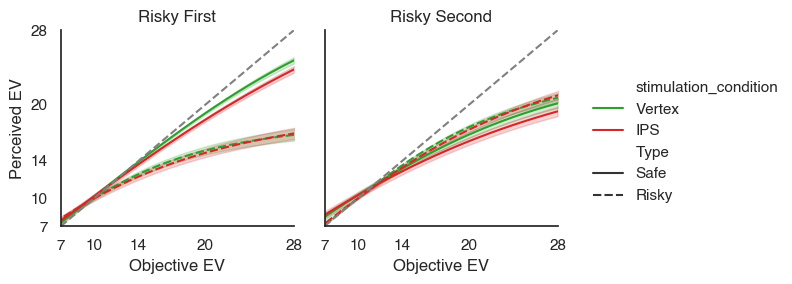

In [126]:
risky_paradigm = pd.MultiIndex.from_product([[True, False], np.arange(7, 58)], names=['risky_first', 'n_risky']).to_frame(index=False)
risky_paradigm['ev'] = .55 * risky_paradigm['n_risky']
risky_paradigm['Order'] = risky_paradigm['risky_first'].map({True: 'Risky First', False: 'Risky Second'})

ev_risky = risky_paradigm.apply(get_ev_risky, axis=1)
ev_risky.index = pd.MultiIndex.from_frame(risky_paradigm)

safe_paradigm = pd.MultiIndex.from_product([[True, False], np.arange(7, 29)], names=['risky_first', 'n_safe']).to_frame(index=False)
safe_paradigm['ev'] = safe_paradigm['n_safe']
safe_paradigm['Order'] = safe_paradigm['risky_first'].map({True: 'Risky First', False: 'Risky Second'})
ev_safe = safe_paradigm.apply(get_ev_safe, axis=1)
ev_safe.index = pd.MultiIndex.from_frame(safe_paradigm)

ev = pd.concat((ev_risky, ev_safe), keys=['Risky', 'Safe'], names=['Type'])

tmp = ev.stack().stack().to_frame('perceived_ev')


g =sns.relplot(data=tmp.reset_index(), x='ev', y='perceived_ev', hue='stimulation_condition', col='Order', kind='line', errorbar='se', palette=stimulation_palette,
            style='Type',
            style_order=['Safe', 'Risky'],
            hue_order=stimulation_order,
            height=3.,
            row_order=['Risky First', 'Risky Second'])


g.set(xticks=[7, 10, 14, 20, 28], yticks=[7, 10, 14, 20, 28])

g.set(xlim=(7, 28), ylim=(7, 28))
g.map(plt.axline, slope=1, xy1=(0, 0), color='gray', linestyle='--')

g.set(ylabel='Perceived EV', xlabel='Objective EV')

g.set_titles('{col_name}')

# Set titlte of first legend to Stimulation condition
g.savefig('/data/ds-tmsrisk/derivatives/figures/nov2025/EV_distortion_1d.pdf', bbox_inches='tight')

# Noise curves

In [139]:
import numpy as np
from scipy.interpolate import interp1d


n_safe = np.arange(7, 28.5, .5)
frac = np.array([1./.55])

n_safe = n_safe[:, np.newaxis]
n_risky = n_safe * frac[np.newaxis, :]
frac = np.repeat(frac[np.newaxis, :], n_safe.shape[0], axis=0)

safe_curves = mean_curves.groupby(['subject', 'stimulation_condition']).apply(lambda d: pd.DataFrame(interp1d(d.index.get_level_values('x').values, d, axis=0)(n_safe.ravel()),
                                                                                    index=pd.Index(n_safe.flatten(), name='x'),
                                                                                    columns=d.columns))

n_safe = np.repeat(n_safe, frac.shape[1], axis=1)

risky_curves = mean_curves.groupby(['subject', 'stimulation_condition']).apply(lambda d: pd.DataFrame(interp1d(d.index.get_level_values('x').values, d, axis=0)(n_risky.ravel()),
                                                                                    index=pd.MultiIndex.from_arrays((n_safe.flatten(),
                                                                                                                     frac.flatten()), names=('n_safe', 'frac')),
                                                                                    columns=d.columns))

risky_curves['ev'] = np.round(.55 * risky_curves.index.get_level_values('n_safe') * risky_curves.index.get_level_values('frac'), 1)
safe_curves['ev'] = safe_curves.index.get_level_values('x')


safe_curves.set_index('ev', append=True, inplace=True)
risky_curves.set_index('ev', append=True, inplace=True)




In [142]:
risky_curves

variable                                            memory_noise_sd  \
subject stimulation_condition n_safe frac     ev                      
1       IPS                   7.0    1.818182 7.0          0.968721   
                              7.5    1.818182 7.5          0.996983   
                              8.0    1.818182 8.0          1.024736   
                              8.5    1.818182 8.5          1.051943   
                              9.0    1.818182 9.0          1.078571   
...                                                             ...   
74      Vertex                26.0   1.818182 26.0         1.878906   
                              26.5   1.818182 26.5         1.892721   
                              27.0   1.818182 27.0         1.906650   
                              27.5   1.818182 27.5         1.920695   
                              28.0   1.818182 28.0         1.934868   

variable                                            perceptual_noise_sd  \
subject stimulation_condition n_safe frac     ev                          
1       IPS                   7.0    1.818182 7.0              0.890009   
                              7.5    1.818182 7.5              0.917658   
                              8.0    1.818182 8.0              0.946517   
                              8.5    1.818182 8.5              0.976548   
                              9.0    1.818182 9.0              1.007709   
...                                                                 ...   
74      Vertex                26.0   1.818182 26.0             3.361537   
                              26.5   1.818182 26.5             3.415740   
                              27.0   1.818182 27.0             3.468530   
                              27.5   1.818182 27.5             3.519923   
                              28.0   1.818182 28.0             3.569790   

variable                                            n1_evidence_sd  \
subject stimulation_condition n_safe frac     ev                     
1       IPS                   7.0    1.818182 7.0         1.858730   
                              7.5    1.818182 7.5         1.914641   
                              8.0    1.818182 8.0         1.971254   
                              8.5    1.818182 8.5         2.028491   
                              9.0    1.818182 9.0         2.086280   
...                                                            ...   
74      Vertex                26.0   1.818182 26.0        5.240443   
                              26.5   1.818182 26.5        5.308461   
                              27.0   1.818182 27.0        5.375180   
                              27.5   1.818182 27.5        5.440618   
                              28.0   1.818182 28.0        5.504658   

variable                                            n2_evidence_sd  
subject stimulation_condition n_safe frac     ev                    
1       IPS                   7.0    1.818182 7.0         0.890009  
                              7.5    1.818182 7.5         0.917658  
                              8.0    1.818182 8.0         0.946517  
                              8.5    1.818182 8.5         0.976548  
                              9.0    1.818182 9.0         1.007709  
...                                                            ...  
74      Vertex                26.0   1.818182 26.0        3.361537  
                              26.5   1.818182 26.5        3.415740  
                              27.0   1.818182 27.0        3.468530  
                              27.5   1.818182 27.5        3.519923  
                              28.0   1.818182 28.0        3.569790  

[3010 rows x 4 columns]

In [141]:
safe_curves

variable                                 memory_noise_sd  perceptual_noise_sd  \
subject stimulation_condition x    ev                                           
1       IPS                   7.0  7.0          0.781952             0.746024   
                              7.5  7.5          0.798631             0.756623   
                              8.0  8.0          0.815311             0.767223   
                              8.5  8.5          0.831886             0.778668   
                              9.0  9.0          0.848461             0.790113   
...                                                  ...                  ...   
74      Vertex                26.0 26.0         1.587830             1.702291   
                              26.5 26.5         1.594000             1.747153   
                              27.0 27.0         1.600170             1.792016   
                              27.5 27.5         1.606404             1.836855   
                              28.0 28.0         1.612639             1.881694   

variable                                 n1_evidence_sd  n2_evidence_sd  
subject stimulation_condition x    ev                                    
1       IPS                   7.0  7.0         1.527976        0.746024  
                              7.5  7.5         1.555255        0.756623  
                              8.0  8.0         1.582533        0.767223  
                              8.5  8.5         1.610554        0.778668  
                              9.0  9.0         1.638575        0.790113  
...                                                 ...             ...  
74      Vertex                26.0 26.0        3.290121        1.702291  
                              26.5 26.5        3.341153        1.747153  
                              27.0 27.0        3.392185        1.792016  
                              27.5 27.5        3.443259        1.836855  
                              28.0 28.0        3.494333        1.881694  

[3010 rows x 4 columns]

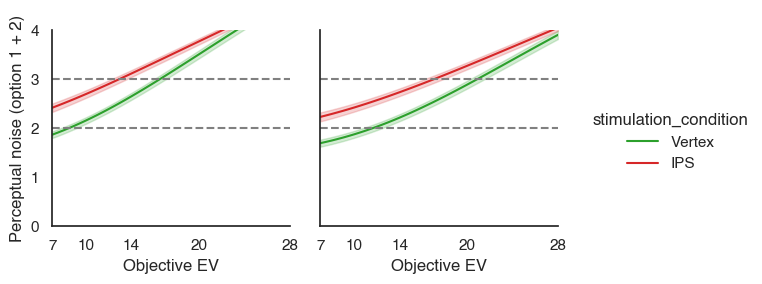

In [138]:
tmp = safe_curves.join(risky_curves.droplevel(['frac', 'n_safe']), lsuffix='_safe', rsuffix='_risky', on=['subject', 'stimulation_condition', 'ev'])

noise_risky_first = np.sqrt(tmp['n1_evidence_sd_risky']**2 + tmp['n2_evidence_sd_safe']**2)
noise_safe_first = np.sqrt(tmp['n2_evidence_sd_risky']**2 + tmp['n1_evidence_sd_safe']**2)
noise = pd.concat((noise_risky_first.to_frame('evidence_sd'),
                   noise_safe_first.to_frame('evidence_sd')), keys=['Risky first', 'Safe first'], names=['Order'])

noise
g = sns.relplot(data=noise.reset_index(), x='ev', y='evidence_sd', hue='stimulation_condition', col='Order', kind='line', errorbar='se', palette=stimulation_palette,
            hue_order=stimulation_order, height=3.,)


g.set(xticks=[7, 10, 14, 20, 28])
g.set(xlim=(7, 28), ylim=(0, 4))

g.set(xlabel='Objective EV', ylabel='Perceptual noise (option 1 + 2)')

g.set_titles(' ', fontweight='bold')

g.map(plt.axhline, y=2, color='gray', linestyle='--')
g.map(plt.axhline, y=3, color='gray', linestyle='--')

# Make title of axes bold
for ax in g.axes.flat:
    ax.title.set_fontweight('bold')

# Set titlte of first legend to Stimulation condition
g.savefig('/data/ds-tmsrisk/derivatives/figures/nov2025/noise_curve.pdf', bbox_inches='tight')


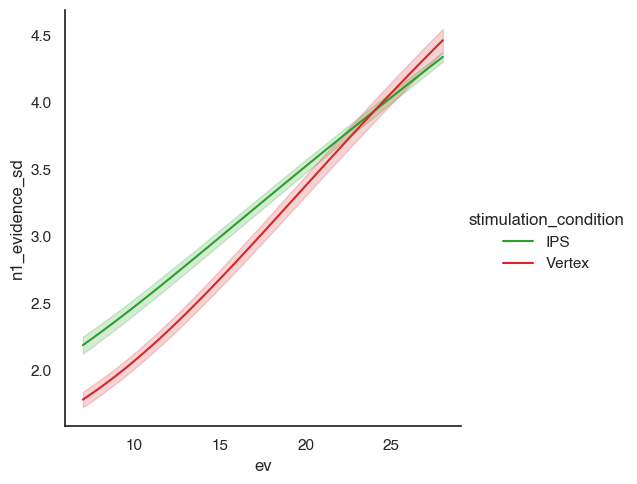

In [147]:
sns.relplot(data=risky_curves.reset_index(), x='ev', y='n1_evidence_sd', hue='stimulation_condition', kind='line', errorbar='se', palette=stimulation_palette,)

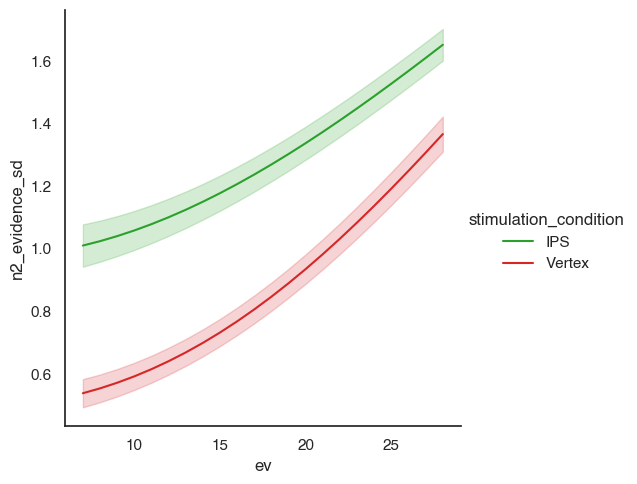

In [149]:
sns.relplot(data=safe_curves.reset_index(), x='ev', y='n2_evidence_sd', hue='stimulation_condition', kind='line', errorbar='se', palette=stimulation_palette,)

In [24]:
tmp

perceived_ev
risky_first stimulation_condition n_risky ev    stimulation_condition subject              
True        Vertex                7.0     3.85  IPS                   1            4.327180
                                                                      2            6.539588
                                                                      3            5.091194
                                                                      4            5.123486
                                                                      5            6.313731
...                                                                                     ...
False       IPS                   56.0    30.80 Vertex                63          22.772946
                                                                      67          19.606700
                                                                      69          25.125213
                                                                      72          22.295380
                                                                      74          15.475904

[14000 rows x 1 columns]